In [49]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [50]:
import sklearn

print(sklearn.__version__)

1.9.0


In [51]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

sns.set_theme(style='whitegrid')
plt.rcParams["figure.figsize"] = (8, 4.5)

df = pd.read_csv('california_housing.csv')

print(f"loaded : {df.shape[0]} California districts, {df.shape[1]} Columns")
df.head()

loaded : 5000 California districts, 9 Columns


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,3.7056,22.0,4.4502,1.1416,1773.0,3.0922,40.02,-122.25,1.7255
1,4.8575,36.0,5.7551,1.0897,199.0,3.6810,37.17,-118.79,2.9542
2,3.3045,9.0,8.6213,1.1102,754.0,3.5749,33.68,-115.29,2.1390
3,2.9988,16.0,6.0610,1.1367,310.0,4.7781,36.92,-122.10,1.9076
4,5.2304,6.0,5.2884,1.1086,1322.0,2.5858,41.01,-123.05,2.9634


Part A — the supervised setup  
TASK 01  
Split and scale  
The preparation every supervised model needs. Get it right or everything downstream is wrong.

In [52]:
# Separate features (X) from the target (y = MedHouseVal).
x = df.drop(columns=['MedHouseVal'])
y = df['MedHouseVal']

print(f"x: {x.shape} features, y: {y.shape} target values")

x: (5000, 8) features, y: (5000,) target values


In [53]:
# Split into training and test sets (80/20), with a fixed random_state so it's reproducible.
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state = 42
)

print("Training Data:")
print('x Train:', x_train.shape)
print('y Train:', y_train.shape)

print("\nTesting Data:")
print("x Test:", x_test.shape)
print("y Test:", y_test.shape)

Training Data:
x Train: (4000, 8)
y Train: (4000,)

Testing Data:
x Test: (1000, 8)
y Test: (1000,)


In [54]:
# Standardize the features: fit the scaler on the TRAINING data only, then transform both train and test.
scaler = StandardScaler().fit(x_train)

x_train_scaled = scaler.transform(x_train)
x_test_scaled = scaler.transform(x_test)

print('Scaled Training Features:')
print('Mean:', x_train_scaled.mean())
print('std:', x_test_scaled.std())

Scaled Training Features:
Mean: -4.671263376110346e-16
std: 0.9997170117336378


* We must not fit the scaler using test data because that would let information from the test set leak into the training process, giving an unrealistic evaluation of the model.

Part B — implement it three ways (the deliverable)  
TASK 02  
Method 1 — the closed-form solution  
The exact answer, straight from linear algebra.

In [55]:
# Add bias column
def add_bias(x_matrix):
    return np.c_[np.ones(len(x_matrix)), x_matrix]

# Add bias to training data
xtr = add_bias(x_train_scaled)

# The normal equation w = (X^T X)^-1 X^T y
w = np.linalg.inv(xtr.T @ xtr) @ xtr.T @ y_train.values

# Print learned weights
print('Bias (Intercept):', w[0])
print('\nFeature weights:')
for feature, weight in zip(x.columns, w[1:]):
    print(f"{feature}: {weight:.6f}")

Bias (Intercept): 2.2094908749999997

Feature weights:
MedInc: 0.879916
HouseAge: 0.169620
AveRooms: 0.033981
AveBedrms: 0.001896
Population: -0.002174
AveOccup: -0.112161
Latitude: -0.149141
Longitude: -0.170009


In [56]:
# Predict the data
xte = add_bias(x_test_scaled)
y_pred = xte @ w

# Calculate Test MSE 
test_mse = mean_squared_error(y_test, y_pred)

print('Test MSE:', test_mse)

Test MSE: 0.1647691521965682


TASK 03  
Method 2 — gradient descent  
The same answer, walked to step by step. The method that scales to everything.

In [57]:
# Start with zero weigts
w_gd = np.zeros(xtr.shape[1])

# Learning Rate and Number of steps
lr = 0.1
steps = 2000

# Store loss at every step
loss_history = []

# Gradient Descent
for step in range(steps):
    # predictions
    y_pred = xtr @ w_gd

    # Error
    error = y_pred - y_train.values

    # MSE loss
    loss = np.mean(error ** 2)
    loss_history.append(loss)

    # Gradient of MSE
    grad = (2 / len(y_train)) * (xtr.T @ error)

    # Update weights
    w_gd -= lr * grad

# print final gradient descent
print("Gradient Descent Weights:")
print("Bias (Intercept):", w_gd[0])

for i, weight in enumerate(w_gd[1:], start=1):
    print(f"Feature {i}, Weight: {weight}")

Gradient Descent Weights:
Bias (Intercept): 2.2094908749999984
Feature 1, Weight: 0.8799155259271888
Feature 2, Weight: 0.16961958777365424
Feature 3, Weight: 0.03398138659237621
Feature 4, Weight: 0.001896071844602776
Feature 5, Weight: -0.002173505800367812
Feature 6, Weight: -0.11216059322130398
Feature 7, Weight: -0.14914137050582588
Feature 8, Weight: -0.17000858018054993


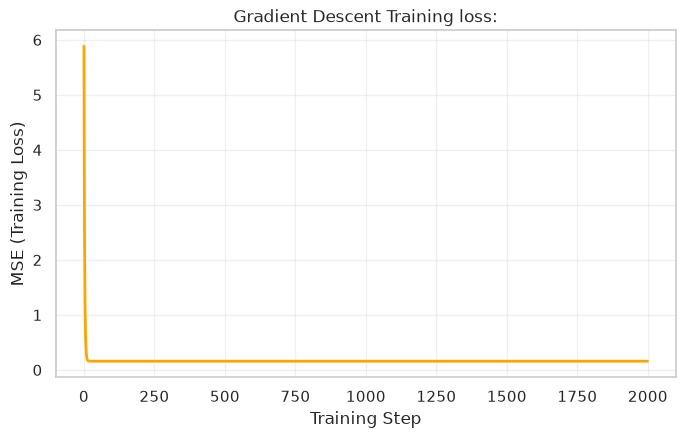


 Loss started at 5.885 and fell to 0.1588


In [58]:
# Plot training loss
fig, ax = plt.subplots()

ax.plot(loss_history, color="orange", lw=2)
ax.set_title("Gradient Descent Training loss:")
ax.set_xlabel("Training Step")
ax.set_ylabel("MSE (Training Loss)")
ax.grid(alpha=0.3)
plt.tight_layout
plt.show()

print(f"\n Loss started at {loss_history[0]:.3f} and fell to {loss_history[-1]:.4f}")

In [59]:
# Compare with closed-form weights
print("Do the two methods agree?")
print("Closed-Form Weights      :", w[:3])
print("Gradient Descent Weights :", w_gd[:3])
print(f"\nMatch? {np.allclose(w, w_gd, atol=1e-3)}")
print("\nDifference:", w_gd - w)

Do the two methods agree?
Closed-Form Weights      : [2.20949087 0.87991553 0.16961959]
Gradient Descent Weights : [2.20949087 0.87991553 0.16961959]

Match? True

Difference: [-1.33226763e-15  3.33066907e-16 -1.94289029e-16 -6.93889390e-18
  2.10335221e-17 -4.77048956e-17 -2.77555756e-17 -5.55111512e-17
  8.32667268e-17]


TASK 04  
Method 3 — sklearn, and prove all three match  
The professional tool, and the deliverable's key proof.

In [66]:
from sklearn.linear_model import LinearRegression

# Fit sklearn Linear Regression
model = LinearRegression()
model.fit(x_train_scaled, y_train)
pred = model.predict(x_test_scaled)

# Get sklearn weights
w_sklearn = np.r_[model.intercept_, model.coef_]

print(f"Sklearn Intercept: {model.intercept_:.4f}")
print("Sklearn Coefficients:", model.coef_[:3].round(4))

Sklearn Intercept: 2.2095
Sklearn Coefficients: [0.8799 0.1696 0.034 ]


In [67]:
# Put all three sets of weights side by side
weights = pd.DataFrame({
    "Closed Form": w,
    "Gradient Descent": w_gd,
    "Sklearn": w_sklearn
})

print("\nComparison of Weights:")
print(weights)


Comparison of Weights:
   Closed Form  Gradient Descent   Sklearn
0     2.209491          2.209491  2.209491
1     0.879916          0.879916  0.879916
2     0.169620          0.169620  0.169620
3     0.033981          0.033981  0.033981
4     0.001896          0.001896  0.001896
5    -0.002174         -0.002174 -0.002174
6    -0.112161         -0.112161 -0.112161
7    -0.149141         -0.149141 -0.149141
8    -0.170009         -0.170009 -0.170009


In [68]:
# Check all three agree?
print("Closed Form vs Sklearn:", 
         np.allclose(w, w_sklearn, atol=1e-5))
print("\nGradient Descent vs Sklearn:",
         np.allclose(w_gd, w_sklearn, atol=1e-5))
print("\nClosed Form vs Gradient Descent:",
         np.allclose(w, w_gd, atol=1e-5))

Closed Form vs Sklearn: True

Gradient Descent vs Sklearn: True

Closed Form vs Gradient Descent: True


In [70]:
pred

array([3.68210434, 1.2899429 , 1.4279813 , 1.32624661, 2.77796395,
       2.46011531, 1.68590675, 1.9673034 , 0.6576236 , 3.72322607,
       1.07059284, 4.05573079, 1.62788677, 1.74974538, 1.82180233,
       1.64295877, 2.71509283, 3.61368812, 2.05312935, 1.24190425,
       1.1478469 , 2.21285802, 1.02970941, 3.25355168, 2.05999932,
       2.28248675, 1.66987489, 2.84451531, 2.87183031, 2.62657522,
       1.96792903, 2.20865208, 1.76151414, 3.8118636 , 1.26877847,
       1.98532219, 1.97165884, 1.68994207, 2.21809361, 2.39533128,
       1.50854657, 2.08698312, 1.11524216, 2.90426903, 1.15756158,
       1.51977686, 2.33380979, 2.6003258 , 3.00545292, 0.83551882,
       2.76264135, 1.53724849, 1.97754476, 2.58379284, 2.16256991,
       2.22520039, 2.15869969, 2.36394456, 3.04977583, 4.53630583,
       1.32101539, 2.10646582, 1.97038418, 1.89457403, 2.48243183,
       3.25469611, 3.90864197, 1.07662444, 2.57233693, 3.85099411,
       2.40400628, 1.43138035, 1.58148531, 1.76272102, 2.25966

What this proves -->  
This proves that sklearn's LinearRegression is effectively solving the same linear regression optimization problem under the hood, producing the same optimal weights as our closed-form and gradient-descent implementations (up to tiny numerical differences).

Part C — measure and interpret  
TASK 05  
Evaluate with four metrics  
Numbers that tell you if the model is any good.

In [72]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Evaluation Metrics
mse = mean_squared_error(y_test, pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, pred)
r2 = r2_score(y_test, pred)

# Print Metrics
print("Test set performance:")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}    -->  Typical Error ${rmse * 100000:,.2f}")
print(f"MAE  : {mae:.4f}    -->  Average Error ${mae * 100000:,.2f}")
print(f"R2   : {r2:.4f}    -->  Explains ${r2 * 100:,.2f}% of the variation in price")

Test set performance:
MSE  : 0.1648
RMSE : 0.4059    -->  Typical Error $40,591.77
MAE  : 0.3193    -->  Average Error $31,932.10
R2   : 0.8383    -->  Explains $83.83% of the variation in price


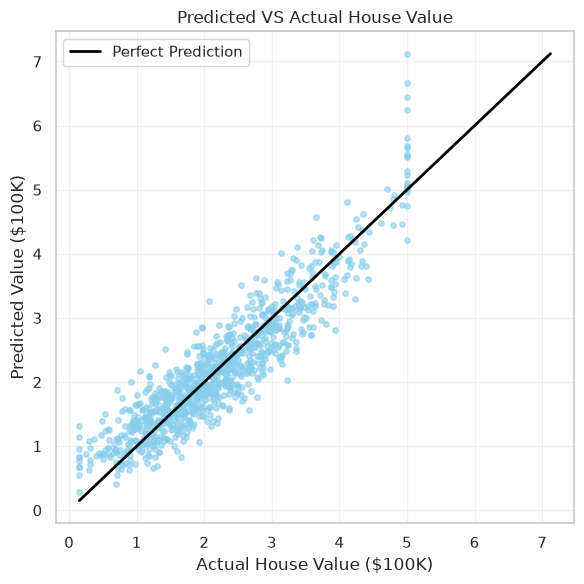

In [75]:
# predicted-vs-actual scatter plot
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, pred, alpha=0.6, color='skyblue', s=15)

# Diagonal line = Perfect Prediction
lim = [
    min(y_test.min(), pred.min()),
    max(y_test.max(), pred.max())
]
ax.plot(lim, lim, color='black', lw=2, ls='-', label='Perfect Prediction')
ax.set_title("Predicted VS Actual House Value")
ax.set_xlabel("Actual House Value ($100K)")
ax.set_ylabel("Predicted Value ($100K)")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

The model performs best for observations whose predicted values lie close to the diagonal line, while larger deviations from the line indicate cases where the model struggles to accurately predict house values.

TASK 06  
Interpret the coefficients (the other deliverable)  
The superpower of linear regression: it explains itself. Say what it learned, in plain English.

In [78]:
# Create Coefficient table
coefs = pd.DataFrame({
    'Features': x.columns,
    'Weights': model.coef_
}).sort_values('Weights', key=abs, ascending=False)

print("Feature weights (largest absolute effect first):")
print(coefs.to_string(index=False))

Feature weights (largest absolute effect first):
  Features   Weights
    MedInc  0.879916
 Longitude -0.170009
  HouseAge  0.169620
  Latitude -0.149141
  AveOccup -0.112161
  AveRooms  0.033981
Population -0.002174
 AveBedrms  0.001896


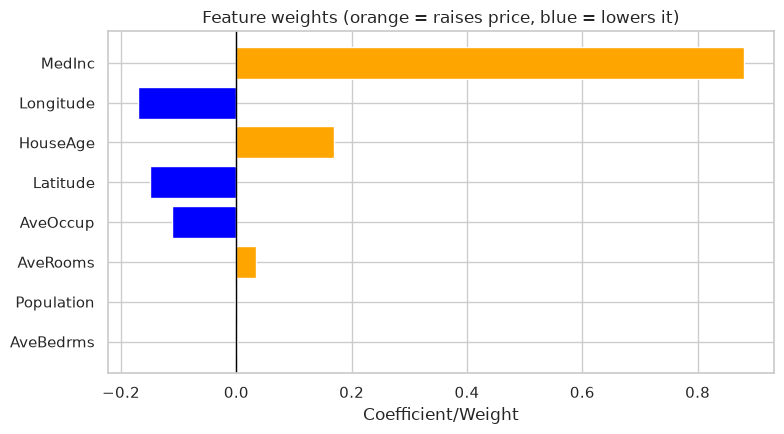

In [80]:
# Plot the chart
fig, ax = plt.subplots()
colors = ['orange' if w > 0 else 'blue' for w in coefs['Weights']]

ax.barh(coefs['Features'], coefs['Weights'], color=colors)

# clear zero line
ax.axvline(0, color='black', lw=1)
ax.set_title("Feature weights (orange = raises price, blue = lowers it)")
ax.set_xlabel("Coefficient/Weight")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

MedInc is the strongest driver of house price because it has the largest absolute coefficient. Its positive coefficient means higher median income is associated with higher predicted house values. Features with negative coefficients push predicted prices downward, while features with positive coefficients push them upward.

Why interpretability matters -->  
Interpretability helps us understand which features are driving predictions and in what direction, making the model easier to explain and trust. More complex models such as random forests and neural networks can sometimes achieve better predictive performance but are harder to interpret because their predictions depend on many interacting nonlinear relationships.